<h1><font color="#113D68" size=5>Redes neuronales y deep learning</font></h1>



<h1><font color="#113D68" size=6>Caso Práctico: análisis de un problema de regresión con Deep Learning</font></h1>


<br><br>
<div style="text-align: right">
<font size=3>Daniel González</font><br>
<font size=3>Semana 3: Ajuste de modelos de Deep Learning</font><br>
<font size=3>IEBS</font>
</div>

---


<h3>Alumno: Adrián Robles Arques</h3>

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [Caso práctico](#section1)
    - [Parte obligatoria](#section1.1)
    - [Parte opcional](#section1.2)
    - [Objetivos](#section1.3)
    - [Criterios de entrega](#section1.4)
    - [Temporalización](#section1.5)
* [California Housing Dataset](#section2)
* [Establecer una función de coste adecuada a nuestro problema](#section3)
* [Overfitting sobre un pequeño conjunto de datos](#section4)
    - [Ejercicio 1](section4.1)
    - [Ejercicio 2](section4.2)
    - [Ejercicio 3](section4.3)
    - [Ejercicio 4](section4.4)
    - [Ejercicio 5](section4.5)
* [Elegimos un Optimizer](#section5)
    - [Ejercicio 6](section5.1)
    - [Ejercicio 7](section5.2)
    - [Ejercicio 8](section5.3)
* [Probar diferentes configuraciones con un número pequeño de epochs](#section6)
    - [Ejercicio 9](section6.1)
    - [Ejercicio 10](section6.2)
* [Ajuste refinado de los parámetros con más epochs](#section7)
    - [Ejercicio 11](section7.1)
    - [Ejercicio 12](section7.2)

In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, InputLayer

# Para mostrar gráficas
import matplotlib.pyplot as plt
%matplotlib inline

# Anaconda fixing problem
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

# <font color="#004D7F" size=5>Caso práctico</font>

El objetivo de este caso práctico es simular como se haría un análisis completo de un problema para resolverlo con Deep Learning. Nos pondremos en la piel de un *data scientist* dedicado a analizar y crear modelos de Deep Learning para pasarlos a producción y ser desplegados en una aplicación.

**Destacar que este caso práctico es la continuación de la última actividad realizada en la semana anterior. En la actividad de la semana anterior encontramos la mejor arquitectura para los datos que tenemos y ahora vmoas a realizar más experimentos jugando con los optimizers y el valor del learning rate.**

Imaginemos que tenemos un dataset completo que queremos explotar, nuestra labor será coger este dataset (California Housing Dataset) y desde 0 intentar llegar conseguir un modelo que tenga un buen rendimiento ajustándolo poco a poco como hemos visto en clase. Por lo que tendrmeos que entrerar distintas redes y comparar los resultados que obtengamos en cada experimento para ver cual es mejor.

Cada experimento que tendremos que realizar estará bien definido, la red que deberéis crear y entrenar será proporcinada por lo que solamente tendréis que crear la red que se nos indica con TensorFlow y realizar el entrenamiento de la misma.

## <font color="#004D7F" size=4>Parte obligatoria</font>

Será obligatorio realizar cada uno de los ejercicios que están definidos. En cada ejercicio está definida la red que se tiene que crear y la configuración con la que se tiene que entrenar, por lo que solamente tendréis que pasar esa definición a código con TensorFlow.

Para tener una buena práctica en la realización de este caso práctico se ofrecen esta recomendaciones:

- Utiliza correctamente el sistema de celdas de jupyter. La libreta está realizada de tal forma que solo tendréis que completar las celdas que se indican, ya sea con código o con texto en markdown. Se recomienda rellenar solamente las celdas indicadas para que quede un informe limpio y fácil de seguir. Si fuera necesario incluir más celdas por cualquier motivo se puede hacer pero realizarlo con cuidado para no ensuciar demasiado la libreta.
<br><br>
- Las redes que tendréis que crear en cada experimento son las vistas en clase, por lo que os podéis inspirar en los ejemplos vistos en los tutoriales. Os recomiendo que no copiéis y peguéis código tal cual, sino que lo escribáis por vuestra cuenta y entendáis lo que estáis haciendo en cada momento. Tomaros el tiempo que haga falta para entender cada paso.
<br><br>
- Comprueba que todo se ejecuta correctamente antes de enviar tu trabajo. La mejor forma de enviarlo es exportando la libreta a pdf o html para enviarla en un formato más profesional.

## <font color="#004D7F" size=4>Parte opcional</font>
La parte opcional son los últimos ejercicios donde tendréis que sacar una conclusión de si la red que habéis llegado a conseguir tiene un buen rendimiento.

## <font color="#004D7F" size=4>Objetivos</font>
* Cargar y entender los datos del dataset California Housing con los que se trabajarán.
* Crear cada una de las redes indicadas en los experimentos.
* Entrenar cada una de las redes creadas en los experimentos.
* Entender los resultados obtenidos en cada entrenamiento.

## <font color="#004D7F" size=4>Criterios de entrega</font>
Se deberá entregar una libreta de jupyter, aunque se agradecerá que el formato entregado se html o pdf, el trabajo debe estar autocontenido, incluyendo código y texto explicativo para cada sección. 

# <font color="#004D7F" size=5>California Housing Dataset</font>
En este notebook vamos a usar un dataset nuevo, el dataset es muy parecido al dataset del precio de las casas de boston. Esta vez vamos a utilizar un conjunto de datos que contienen información sobre el precio de las casas encontradas en un distrito de California. Las columnas son las siguientes:

- _longitude_: cuanto de al oeste está una casa; un valor más alto está más al oeste.
- _latitude_: cuanto de al norte está una casa; un valor más alto está más al norte.
- _housing_median_age_: edad media de una casa; un valor bajo es una casa más nueva.
- _total_rooms_: número total de habitaciones.
- _total_bedrooms_: número total de dormitorios.
- _population_: número total de personas que residen.
- _households_: número total de hogares, un grupo de personas que residen dentro de una unidad de vivienda.
- _median_income_: ingreso medio de los hogares dentro de un bloque de casas (medido en decenas de miles de dólares).
- _ocean_proximity_: ubicación de la casa cerca del océano o mar.
- _median_house_value (**variables a predecir**)_: valor medio de la vivienda (medido en dólares).

Vamos a cargar los datos desde el fichero `housing.csv`:

In [2]:
df = pd.read_csv('housing.csv')

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,3,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3,342200.0


In [4]:
df.shape

(20433, 10)

Vamos a separar la variable objetivo del resto de variables (accedemos al campo value para que los datos sean de tipo _numpy array_ y se puedan usar como variable de entrada de nuestra red):

In [5]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='object')

In [6]:
x = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity']].values
y = df[['median_house_value']].values

## 1. Establecer una función de coste adecuada a nuestro problema.

En este caso, como es un problema de regresión y los valores de nuestros datos son tan grandes, elegimos la función de coste `mean_absolute_percentage_error`, este error varía entre los valores 100 y 0 donde 100 es el pero error que podemos llegar a tener y 0 es el mejor error, por lo que en nuestros entrenamientos buscaremos un error más cercano a 0.

In [8]:
actual_loss = 'mean_absolute_percentage_error'

## 2. Overfitting sobre un pequeño conjunto de datos.

Ahora, como ya hemos visto en clase vamos a encontrar una estructura de red que encaje con los datos que vamos a utilizar. Vamos a crear varias redes a ver que talfuncionan.

Para hacer entrenamientos rápidos y ver si la red se adapta a los datos vamos a usar solo un subconjunto de los datos, es decir usaremos 1000 datos y no usaremos conjunto de validación. 

### <font color="#004D7F" size=4>Ejercicio 1</font>

Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 8 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 8 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.
        
    - Tipo de entrenamiento:
        - *Epochs*: 30
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001

In [9]:
# Vamos a tomar 1000 muestras aleatoriamente para el entrenamiento rápido

# Creamos una lista de 1000 números aleatorios entre 0 y el número de filas del DataFrame
np.random.seed(42) #Ajustamos la semilla para que sea reproducible
random_index = np.random.randint(0, len(df), 1000)

# Creamos un nuevo dataframe con las filas aleatorias
x_ftrain = df.iloc[random_index, :-1].copy()  # Excluimos la última columna (median_house_value) para x_train
y_ftrain = df.iloc[random_index, -1].copy()   # Seleccionamos solo la última columna para y_train

In [10]:
x_ftrain.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
15795,-122.43,37.73,52.0,3602.0,738.0,2270.0,647.0,3.8934,3
860,-122.04,37.57,12.0,5719.0,1064.0,3436.0,1057.0,5.2879,3
5390,-118.42,34.01,42.0,1594.0,369.0,952.0,362.0,3.0990,0
11964,-117.54,33.76,5.0,5846.0,1035.0,3258.0,1001.0,4.7965,0
11284,-117.97,33.72,24.0,2991.0,500.0,1437.0,453.0,5.4286,0


In [13]:
# Creamos la arquitectura de la red neuronal
model = Sequential()
model.add(InputLayer(input_shape=9))
model.add(Dense(8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation=None))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 80        
                                                                 
 dense_1 (Dense)             (None, 8)                 72        
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 161
Trainable params: 161
Non-trainable params: 0
_________________________________________________________________


Epoch 1/30
32/32 [==============================] - 1s 2ms/step - loss: 100.0826
Epoch 2/30
32/32 [==============================] - 0s 1ms/step - loss: 99.9772
Epoch 3/30
32/32 [==============================] - 0s 1ms/step - loss: 99.8353
Epoch 4/30
32/32 [==============================] - 0s 1ms/step - loss: 99.6823
Epoch 5/30
32/32 [==============================] - 0s 1ms/step - loss: 99.4631
Epoch 6/30
32/32 [==============================] - 0s 1ms/step - loss: 99.1531
Epoch 7/30
32/32 [==============================] - 0s 1ms/step - loss: 98.7051
Epoch 8/30
32/32 [==============================] - 0s 1ms/step - loss: 98.1064
Epoch 9/30
32/32 [==============================] - 0s 952us/step - loss: 97.3399
Epoch 10/30
32/32 [==============================] - 0s 1ms/step - loss: 96.4537
Epoch 11/30
32/32 [==============================] - 0s 1ms/step - loss: 95.3881
Epoch 12/30
32/32 [==============================] - 0s 962us/step - loss: 94.0608
Epoch 13/30
32/32 [=============

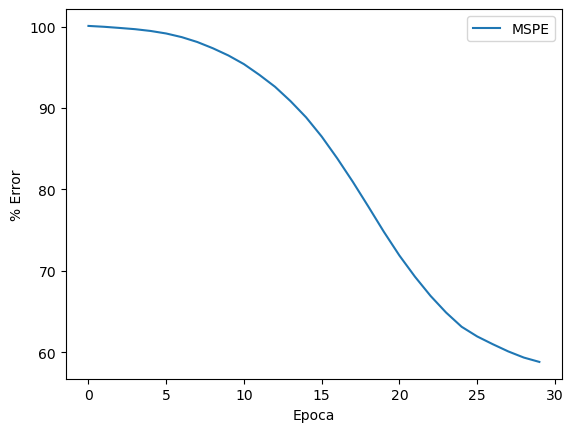

In [14]:
# Compilamos el modelo
model.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo
history = model.fit(x_ftrain, y_ftrain, epochs=30, batch_size=32, verbose=1)

# Graficamos la evolución de la función de pérdida
plt.plot(history.history['loss'], label='MSPE')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.legend()
plt.show()

### <font color="#004D7F" size=4>Ejercicio 2</font>

Vamos a complicar un poco más la arquitectura de la red:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 64 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *5º Capa*: capa de salida con una neurona sin función de activación.
        
    - Tipo de entrenamiento:
        - *Epochs*: 30
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001

In [15]:
# Creamos la arquitectura de la red neuronal
model2 = Sequential()
model2.add(InputLayer(input_shape=9))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1))

model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                640       
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 32)                1056      
                                                                 
 dense_6 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3,809
Trainable params: 3,809
Non-trainable params: 0
_________________________________________________________________


Epoch 1/30
32/32 [==============================] - 0s 1ms/step - loss: 98.8703
Epoch 2/30
32/32 [==============================] - 0s 1ms/step - loss: 93.6558
Epoch 3/30
32/32 [==============================] - 0s 1ms/step - loss: 77.1777
Epoch 4/30
32/32 [==============================] - 0s 1ms/step - loss: 58.9687
Epoch 5/30
32/32 [==============================] - 0s 1ms/step - loss: 58.2821
Epoch 6/30
32/32 [==============================] - 0s 1ms/step - loss: 57.7659
Epoch 7/30
32/32 [==============================] - 0s 2ms/step - loss: 57.4740
Epoch 8/30
32/32 [==============================] - 0s 1ms/step - loss: 57.2662
Epoch 9/30
32/32 [==============================] - 0s 2ms/step - loss: 56.9848
Epoch 10/30
32/32 [==============================] - 0s 1ms/step - loss: 56.9367
Epoch 11/30
32/32 [==============================] - 0s 1ms/step - loss: 56.3895
Epoch 12/30
32/32 [==============================] - 0s 1ms/step - loss: 56.1351
Epoch 13/30
32/32 [==================

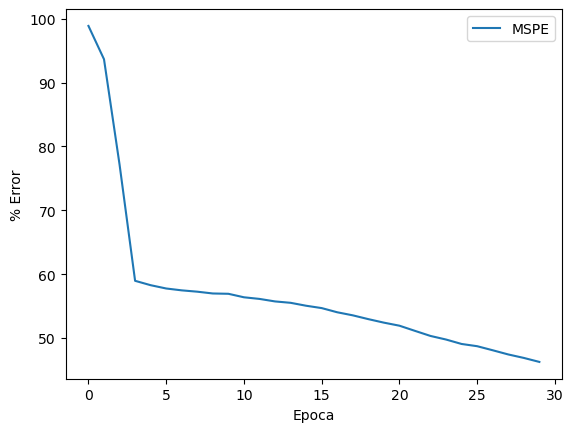

In [16]:
# Compilamos el modelo
model2.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo
history2 = model2.fit(x_ftrain, y_ftrain, epochs=30, batch_size=32, verbose=1)

# Graficamos la evolución de la función de pérdida
plt.plot(history2.history['loss'], label='MSPE')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.legend()
plt.show()

### <font color="#004D7F" size=4>Ejercicio 3</font>

Vamos a complicar aun más la arquitectura de la red:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 128 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 64 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *5º Capa*: capa densa con 16 neuronas y función de activación *relu*.
        - *6º Capa*: capa de salida con una neurona sin función de activación.
        
    - Tipo de entrenamiento:
        - *Epochs*: 30
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001

In [17]:
# Creamos la arquitectura de la red neuronal
model3 = Sequential()
model3.add(InputLayer(input_shape=9))
model3.add(Dense(128, activation='relu'))
model3.add(Dense(64, activation='relu'))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(16, activation='relu'))
model3.add(Dense(1))

model3.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 128)               1280      
                                                                 
 dense_8 (Dense)             (None, 64)                8256      
                                                                 
 dense_9 (Dense)             (None, 32)                2080      
                                                                 
 dense_10 (Dense)            (None, 16)                528       
                                                                 
 dense_11 (Dense)            (None, 1)                 17        
                                                                 
Total params: 12,161
Trainable params: 12,161
Non-trainable params: 0
_________________________________________________________________


Epoch 1/30
32/32 [==============================] - 1s 2ms/step - loss: 98.3421
Epoch 2/30
32/32 [==============================] - 0s 1ms/step - loss: 85.5536
Epoch 3/30
32/32 [==============================] - 0s 1ms/step - loss: 61.1719
Epoch 4/30
32/32 [==============================] - 0s 1ms/step - loss: 57.9879
Epoch 5/30
32/32 [==============================] - 0s 1ms/step - loss: 57.7130
Epoch 6/30
32/32 [==============================] - 0s 1ms/step - loss: 57.4078
Epoch 7/30
32/32 [==============================] - 0s 1ms/step - loss: 56.8233
Epoch 8/30
32/32 [==============================] - 0s 1ms/step - loss: 56.6396
Epoch 9/30
32/32 [==============================] - 0s 1ms/step - loss: 56.2269
Epoch 10/30
32/32 [==============================] - 0s 1ms/step - loss: 55.6263
Epoch 11/30
32/32 [==============================] - 0s 1ms/step - loss: 55.2702
Epoch 12/30
32/32 [==============================] - 0s 1ms/step - loss: 55.0234
Epoch 13/30
32/32 [==================

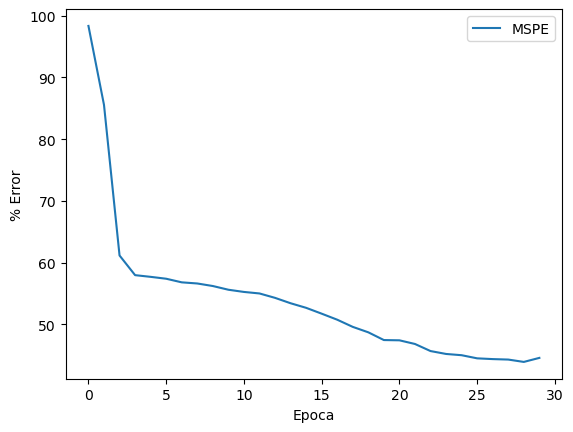

In [18]:
# Compilamos el modelo
model3.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo
history3 = model3.fit(x_ftrain, y_ftrain, epochs=30, batch_size=32, verbose=1)

# Graficamos la evolución de la función de pérdida
plt.plot(history3.history['loss'], label='MSPE')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.legend()
plt.show()

### <font color="#004D7F" size=4>Ejercicio 4</font>

Vamos a hacer una última red con más capas y neuronas:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 1024 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 512 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 256 neuronas y función de activación *relu*.
        - *5º Capa*: capa densa con 128 neuronas y función de activación *relu*.
        - *6º Capa*: capa densa con 64 neuronas y función de activación *relu*.
        - *7º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *8º Capa*: capa densa con 16 neuronas y función de activación *relu*.
        - *9º Capa*: capa de salida con una neurona sin función de activación.
        
    - Tipo de entrenamiento:
        - *Epochs*: 30
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001

In [19]:
# Creamos la arquitectura de la red neuronal
model4 = Sequential()
model4.add(InputLayer(input_shape=9))
for i in range(7):
    model4.add(Dense(8*2**(7-i), activation='relu'))
model4.add(Dense(1))

model4.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 1024)              10240     
                                                                 
 dense_13 (Dense)            (None, 512)               524800    
                                                                 
 dense_14 (Dense)            (None, 256)               131328    
                                                                 
 dense_15 (Dense)            (None, 128)               32896     
                                                                 
 dense_16 (Dense)            (None, 64)                8256      
                                                                 
 dense_17 (Dense)            (None, 32)                2080      
                                                                 
 dense_18 (Dense)            (None, 16)               

Epoch 1/30
32/32 [==============================] - 1s 4ms/step - loss: 77.0866
Epoch 2/30
32/32 [==============================] - 0s 3ms/step - loss: 60.4067
Epoch 3/30
32/32 [==============================] - 0s 4ms/step - loss: 56.6283
Epoch 4/30
32/32 [==============================] - 0s 4ms/step - loss: 56.8554
Epoch 5/30
32/32 [==============================] - 0s 3ms/step - loss: 53.0583
Epoch 6/30
32/32 [==============================] - 0s 3ms/step - loss: 49.0798
Epoch 7/30
32/32 [==============================] - 0s 4ms/step - loss: 46.1804
Epoch 8/30
32/32 [==============================] - 0s 3ms/step - loss: 48.0698
Epoch 9/30
32/32 [==============================] - 0s 3ms/step - loss: 46.9954
Epoch 10/30
32/32 [==============================] - 0s 3ms/step - loss: 45.0106
Epoch 11/30
32/32 [==============================] - 0s 4ms/step - loss: 43.6079
Epoch 12/30
32/32 [==============================] - 0s 3ms/step - loss: 45.8135
Epoch 13/30
32/32 [==================

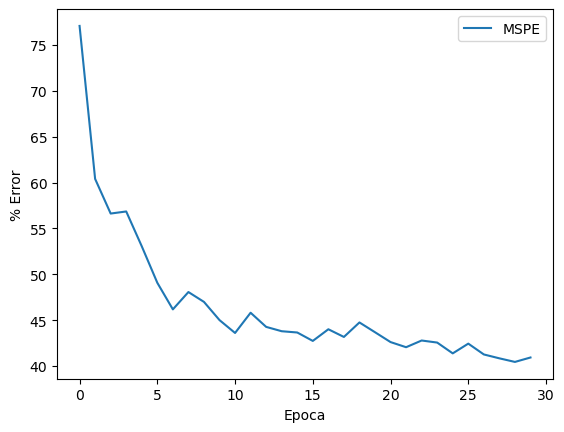

In [20]:
# Compilamos el modelo
model4.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo
history4 = model4.fit(x_ftrain, y_ftrain, epochs=30, batch_size=32, verbose=1)

# Graficamos la evolución de la función de pérdida
plt.plot(history4.history['loss'], label='MSPE')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.legend()
plt.show()

### <font color="#004D7F" size=4>Ejercicio 5</font>
Compara los resultados obtenidos en cada una de las arquitecturas definidas y quédate con la mejor. **¿En qué experimento se obtiene los mejores resultados?**

La arquitectura elegida la usaremos en el caso práctico para seguir ajustando nuestro modelo y alcanzar un buen rendimiento.

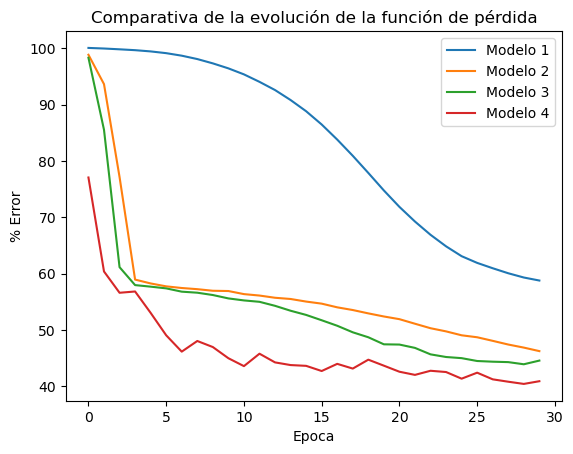

In [22]:
# Representamos la evolución de las funciones de pérdida de los cuatro modelos
plt.plot(history.history['loss'], label='Modelo 1')
plt.plot(history2.history['loss'], label='Modelo 2')
plt.plot(history3.history['loss'], label='Modelo 3')
plt.plot(history4.history['loss'], label='Modelo 4')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.title('Comparativa de la evolución de la función de pérdida')
plt.legend()
plt.show()

De acuerdo con los resultados y gráficos para cada modelo, aunque el valor mínimo que se alcanza en la función de error para los modelos tercero y cuarto es inferior, considero que el segundo modelo es el indicado para la solución del problema. Mi alternativa más cercana sería el tercero, ya que tiene un valor mínimo de la función de pérdida con escasas fluctuaciones, pero dado que el segundo obtiene resultados muy similares con menor complejidad, y por ende menos coste computacional y menor tendencia al sobreajuste, creo que es más indicado. El modelo elegido es suficientemente complejo para este problema, y no tan complejo como para introducir errores artificiales, además de ahorrar en costes y tiempo de entrenamiento, gracias a sus poco más de 3000 parámetros configurables, frente a los más de 12000 del tercer modelo, o más de 710000 del último. El primero, por su parte, sería demasiado simple y poco eficiente puesto que tardaría mucho en converger a una solución, si es que lo logra.

## 3. Elegimos un Optimizer.

Hemos establecido Adam en los entrenamientos anteriores. Vamos a comprobarlo para el conjunto de validación como funciona y después probaremos a usar un optimizador SGD.

### <font color="#004D7F" size=4>Ejercicio 6</font>

Usa la mejor arquitectura y configuración de entrenamiento de los ejercicios anteriores y entrena con la siguiente configuración:

- Usa un `validation_split` de 0.2
- Utiliza todos los datos y no solo 1000.
- Usa 5 epochs en total.

In [28]:
# Creamos la arquitectura de la red neuronal, introduciendo el modelo en una función

def final_model():
    modelf = Sequential()
    modelf.add(InputLayer(input_shape=9))
    modelf.add(Dense(64, activation='relu'))
    modelf.add(Dense(32, activation='relu'))
    modelf.add(Dense(32, activation='relu'))
    modelf.add(Dense(1))

    modelf.summary()
    
    return modelf

modelf = final_model()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_28 (Dense)            (None, 64)                640       
                                                                 
 dense_29 (Dense)            (None, 32)                2080      
                                                                 
 dense_30 (Dense)            (None, 32)                1056      
                                                                 
 dense_31 (Dense)            (None, 1)                 33        
                                                                 
Total params: 3,809
Trainable params: 3,809
Non-trainable params: 0
_________________________________________________________________


Epoch 1/5
511/511 [==============================] - 3s 4ms/step - loss: 60.8542 - val_loss: 52.9585
Epoch 2/5
511/511 [==============================] - 2s 4ms/step - loss: 45.9221 - val_loss: 47.7257
Epoch 3/5
511/511 [==============================] - 2s 3ms/step - loss: 42.2661 - val_loss: 47.4241
Epoch 4/5
511/511 [==============================] - 1s 3ms/step - loss: 41.7028 - val_loss: 47.4138
Epoch 5/5
511/511 [==============================] - 2s 4ms/step - loss: 41.2972 - val_loss: 46.8387


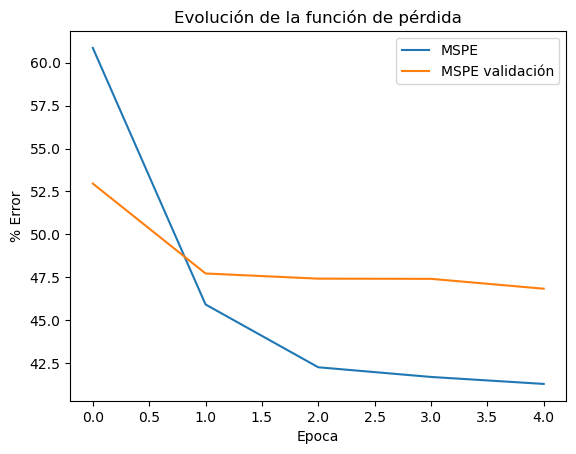

In [29]:
# Compilamos el modelo
modelf.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Entrenamos el modelo con los datos completos
historyf = modelf.fit(x, y, epochs=5, batch_size=32, verbose=1, validation_split=0.2)

# Graficamos la evolución de la función de pérdida
plt.plot(historyf.history['loss'], label='MSPE')
plt.plot(historyf.history['val_loss'], label='MSPE validación')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.title('Evolución de la función de pérdida')
plt.legend()
plt.show()

### <font color="#004D7F" size=4>Ejercicio 7</font>

Realiza el mismo entrenamiento que el ejercicio anterior pero usa un optimizador **SGD** en lugar de un Adam.

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_32 (Dense)            (None, 64)                640       
                                                                 
 dense_33 (Dense)            (None, 32)                2080      
                                                                 
 dense_34 (Dense)            (None, 32)                1056      
                                                                 
 dense_35 (Dense)            (None, 1)                 33        
                                                                 
Total params: 3,809
Trainable params: 3,809
Non-trainable params: 0
_________________________________________________________________
Epoch 1/5
511/511 [==============================] - 4s 7ms/step - loss: 86.8449 - val_loss: 56.8418
Epoch 2/5
511/511 [==============================] - 2s 5ms/step - loss: 56.5505 - 

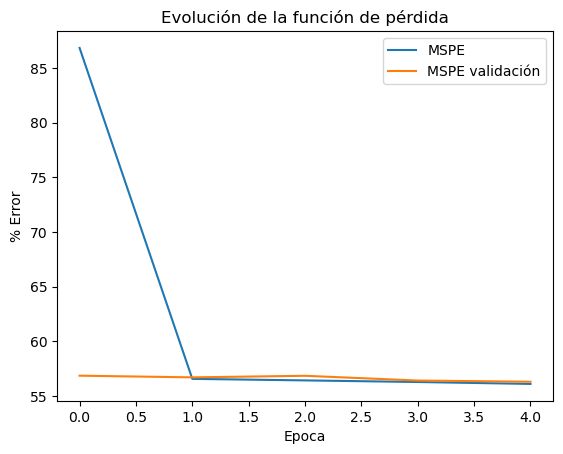

In [30]:
# Llamamos al modelo
modelf2 = final_model()

# Compilamos el modelo
modelf2.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.SGD(learning_rate=0.001))

# Entrenamos el modelo
historyf2 = modelf2.fit(x, y, epochs=5, batch_size=32, verbose=1, validation_split=0.2)

# Graficamos la evolución de la función de pérdida
plt.plot(historyf2.history['loss'], label='MSPE')
plt.plot(historyf2.history['val_loss'], label='MSPE validación')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.title('Evolución de la función de pérdida')
plt.legend()
plt.show()

### <font color="#004D7F" size=4>Ejercicio 8</font>

**¿Qué optimizador ha funcionado mejor?**

El optimizador que eligas tendrás que usarlo en los siguientes ejercicios.

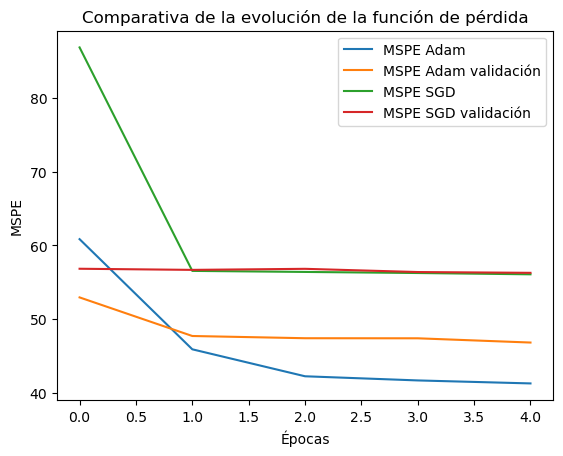

In [31]:
# Vamos a comparar las gráficas de ambos modelos
plt.plot(historyf.history['loss'], label='MSPE Adam')
plt.plot(historyf.history['val_loss'], label='MSPE Adam validación')
plt.plot(historyf2.history['loss'], label='MSPE SGD')
plt.plot(historyf2.history['val_loss'], label='MSPE SGD validación')
plt.xlabel('Épocas')
plt.ylabel('MSPE')
plt.title('Comparativa de la evolución de la función de pérdida')
plt.legend()
plt.show()

De acuerdo a los resultados previos con el entrenamiento en tan solo 5 épocas, para este problema el uso del optimizador Adam parece más indicado que el SGD.

## 4. Probar diferentes configuraciones con un número pequeño de epochs.

Vamos a realizar diferentes experimentos cambiando el learning rate de nuestro optimizador.

### <font color="#004D7F" size=4>Ejercicio 9</font>

Realiza un entrenamiento con la arquitectura y el optimizador que mejor te ha funcionado y utilizar un **learning rate de 0.1**.

In [38]:
# Llamamos al modelo
model_ej9 = final_model()

# Compilamos el modelo
model_ej9.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.1))

# Entrenamos el modelo
history_ej9 = model_ej9.fit(x, y, epochs=5, batch_size=32, verbose=1, validation_split=0.2)

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_44 (Dense)            (None, 64)                640       
                                                                 
 dense_45 (Dense)            (None, 32)                2080      
                                                                 
 dense_46 (Dense)            (None, 32)                1056      
                                                                 
 dense_47 (Dense)            (None, 1)                 33        
                                                                 
Total params: 3,809
Trainable params: 3,809
Non-trainable params: 0
_________________________________________________________________
Epoch 1/5
511/511 [==============================] - 3s 4ms/step - loss: 46.2615 - val_loss: 47.5540
Epoch 2/5
511/511 [==============================] - 2s 4ms/step - loss: 40.8688 -

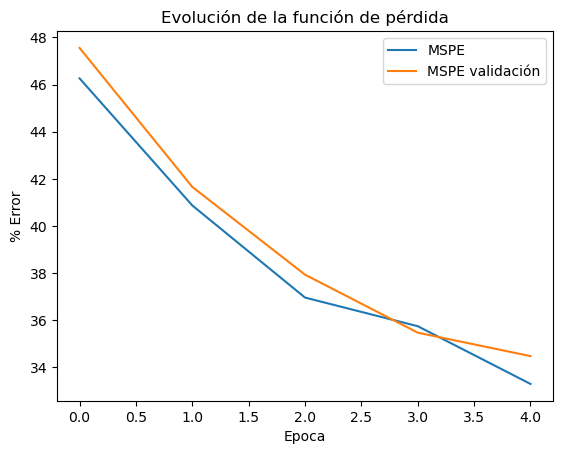

In [39]:
# Graficamos la evolución de la función de pérdida
plt.plot(history_ej9.history['loss'], label='MSPE')
plt.plot(history_ej9.history['val_loss'], label='MSPE validación')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.title('Evolución de la función de pérdida')
plt.legend()
plt.show()

### <font color="#004D7F" size=4>Ejercicio 10</font>

Realiza el mismo entrenamiento que el ejercicio anterior pero esta vez usa un **learning rate de 0.0001**.

In [40]:
# Llamamos al modelo
model_ej10 = final_model()

# Compilamos el modelo
model_ej10.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

# Entrenamos el modelo
history_ej10 = model_ej10.fit(x, y, epochs=5, batch_size=32, verbose=1, validation_split=0.2)

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_48 (Dense)            (None, 64)                640       
                                                                 
 dense_49 (Dense)            (None, 32)                2080      
                                                                 
 dense_50 (Dense)            (None, 32)                1056      
                                                                 
 dense_51 (Dense)            (None, 1)                 33        
                                                                 
Total params: 3,809
Trainable params: 3,809
Non-trainable params: 0
_________________________________________________________________
Epoch 1/5
511/511 [==============================] - 4s 5ms/step - loss: 98.0429 - val_loss: 92.7164
Epoch 2/5
511/511 [==============================] - 2s 4ms/step - loss: 72.0746 -

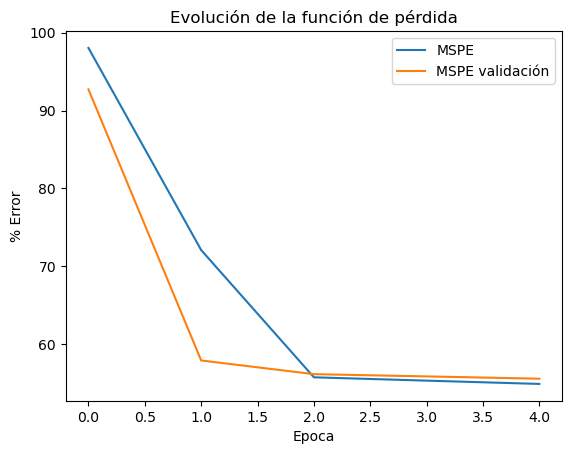

In [41]:
# Graficamos la evolución de la función de pérdida
plt.plot(history_ej10.history['loss'])
plt.plot(history_ej10.history['val_loss'])
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.title('Evolución de la función de pérdida')
plt.legend(['MSPE', 'MSPE validación'])
plt.show()

## 5. Ajuste refinado de los parámetros con más epochs. [Opcional]

Por último vamos a realizar un entrenamiento más largo para ver hasta donde llega el rendimiento de nuestro modelo.

### <font color="#004D7F" size=4>Ejercicio 11 [Opcional]</font> 

**¿Entre los entrenamientos usando learning rates igual a 0.001, 0.1 y 0.0001 cual ha funcionado mejor?**

Con el experimento que mejor haya funcionado haz un entrenamiento usando 30 epochs y ver que tal funciona el entrenamiento con más epochs.

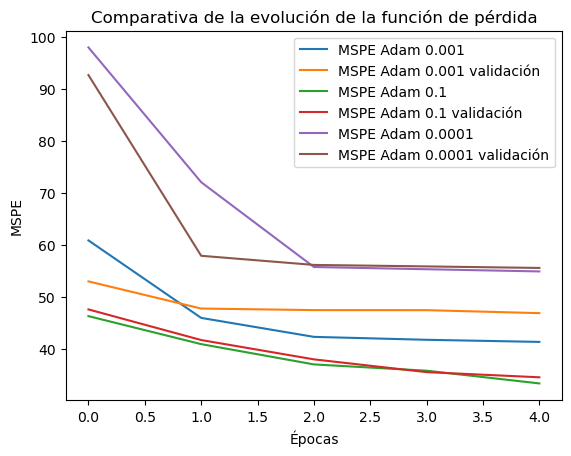

In [42]:
# Comparativa de la evolución de la función de pérdida de los tres learning rates
plt.plot(historyf.history['loss'], label='MSPE Adam 0.001')
plt.plot(historyf.history['val_loss'], label='MSPE Adam 0.001 validación')
plt.plot(history_ej9.history['loss'], label='MSPE Adam 0.1')
plt.plot(history_ej9.history['val_loss'], label='MSPE Adam 0.1 validación')
plt.plot(history_ej10.history['loss'], label='MSPE Adam 0.0001')
plt.plot(history_ej10.history['val_loss'], label='MSPE Adam 0.0001 validación')
plt.xlabel('Épocas')
plt.ylabel('MSPE')
plt.title('Comparativa de la evolución de la función de pérdida')
plt.legend()
plt.show()

Aparentemente el mejor resultado lo obtenemos con un learning rate de 0.1, ya que minimiza el error rápidamente y parece que sigue teniendo margen de mejora.

In [43]:
# Llamamos al modelo
model_ej11 = final_model()

# Compilamos el modelo
model_ej11.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.1))

# Entrenamos el modelo
history_ej11 = model_ej11.fit(x, y, epochs=30, batch_size=32, verbose=1, validation_split=0.2)

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_52 (Dense)            (None, 64)                640       
                                                                 
 dense_53 (Dense)            (None, 32)                2080      
                                                                 
 dense_54 (Dense)            (None, 32)                1056      
                                                                 
 dense_55 (Dense)            (None, 1)                 33        
                                                                 
Total params: 3,809
Trainable params: 3,809
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30
511/511 [==============================] - 3s 5ms/step - loss: 46.3513 - val_loss: 45.9255
Epoch 2/30
511/511 [==============================] - 2s 5ms/step - loss: 41.4153

### <font color="#004D7F" size=4>Ejercicio 12 [Opcional]</font> 

Muestra en una gráfica como ha evolucionado el entrenamiento.

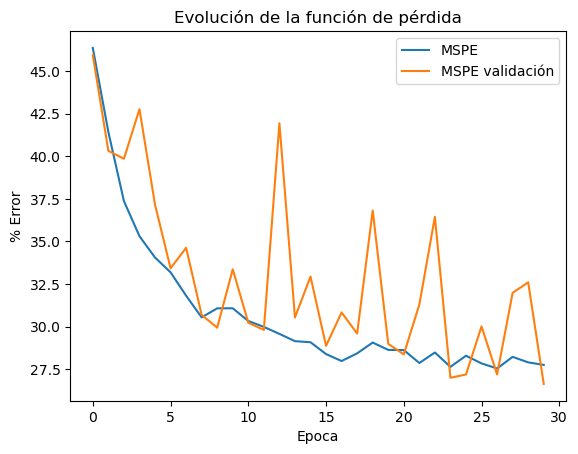

In [44]:
# Graficamos el resultado del último entrenamiento
plt.plot(history_ej11.history['loss'])
plt.plot(history_ej11.history['val_loss'])
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.title('Evolución de la función de pérdida')
plt.legend(['MSPE', 'MSPE validación'])
plt.show()

Vemos que aunque ciertamente minimiza el error, el resultado en validación oscila mucho, lo que nos indica que tal vez sería más aconsejable emplear un modelo con un learning rate menor. Vamos a probar un nuevo valor y con más épocas de entrenamiento.

In [51]:
# importamos el módulo de EarlyStopping
from keras.callbacks import EarlyStopping

# Llamamos al modelo
model_opt = final_model()

# Compilamos el modelo
model_opt.compile(loss=actual_loss,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# Definimos el EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Entrenamos el modelo
history_opt = model_opt.fit(x, y, epochs=100, batch_size=32, verbose=1, validation_split=0.2, callbacks=[early_stopping])


Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_68 (Dense)            (None, 64)                640       
                                                                 
 dense_69 (Dense)            (None, 32)                2080      
                                                                 
 dense_70 (Dense)            (None, 32)                1056      
                                                                 
 dense_71 (Dense)            (None, 1)                 33        
                                                                 
Total params: 3,809
Trainable params: 3,809
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
511/511 [==============================] - 4s 6ms/step - loss: 61.8409 - val_loss: 53.5315
Epoch 2/100
511/511 [==============================] - 2s 5ms/step - loss: 46.21

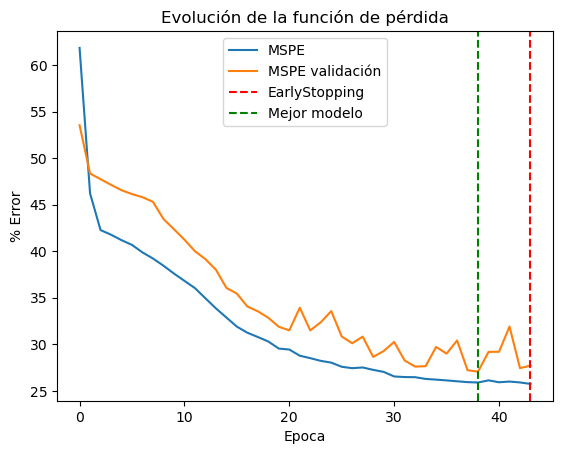

In [52]:
# Graficamos el resultado del último entrenamiento, marcando el EarlyStopping
# y el modelo con el mejor resultado
plt.plot(history_opt.history['loss'], label='MSPE')
plt.plot(history_opt.history['val_loss'], label='MSPE validación')
plt.axvline(x=early_stopping.stopped_epoch, color='r', linestyle='--', label='EarlyStopping')
plt.axvline(x=early_stopping.best_epoch, color='g', linestyle='--', label='Mejor modelo')
plt.ylabel('% Error')
plt.xlabel('Epoca')
plt.title('Evolución de la función de pérdida')
plt.legend()
plt.show()


En este caso vemos cómo se ha alcanzado una tasa de error inferior al anterior, con menor oscilación en la tasa de error de validación. La implementación del Early Stopping nos permite frenar el entrenamiento una vez se ha dado la convergencia del modelo de forma automática, antes de que se entre en una fase de overfitting, y recuperar los pesos del mejor resultado obtenido en la fase de validación, que es lo que el callback del Early Stopping monitoriza.